In [6]:
!pip install nltk
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
!pip install nltk wordcloud seaborn scikit-learn matplotlib pandas numpy


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Zarna\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zarna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Zarna\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Zarna\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
#Import Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# WordCloud
from wordcloud import WordCloud

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Importing Required Libraries

In this step, we import all the libraries required for data manipulation, visualization, natural language processing (NLP), machine learning model building, evaluation, and word cloud generation. These libraries provide the essential tools needed throughout the sentiment analysis pipeline.

In [8]:

# Load the dataset
df = pd.read_csv("sentiment_data.csv")

# Display first 5 rows
df.head()

,Index,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


## Loading the Dataset

The dataset is loaded into a Pandas DataFrame using `pd.read_csv()`. A DataFrame is a two-dimensional table-like data structure used for storing and analyzing data. The `head()` function is used to display the first five rows to verify that the dataset has been loaded correctly.

In [9]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Information about the dataset
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (241145, 3)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   Index      241145 non-null  int64
 1   Comment    240928 non-null  str  
 2   Sentiment  241145 non-null  int64
dtypes: int64(2), str(1)
memory usage: 5.5 MB

Statistical Summary:


,Index,Sentiment
count,241145.000000,241145.000000
mean,121289.252479,1.198822
std,69709.762092,0.785110
min,0.000000,0.000000
25%,61063.000000,1.000000
50%,121350.000000,1.000000
75%,181636.000000,2.000000
max,241925.000000,2.000000



Missing Values:
Index          0
Comment      217
Sentiment      0
dtype: int64


## Dataset Inspection

Before building the machine learning model, the dataset is inspected to understand its structure and quality.

- `shape` displays the number of rows and columns.
- `info()` provides column names, data types, and missing value information.
- `describe()` summarizes numerical columns.
- `isnull().sum()` checks for missing values in each column.

In [10]:
# Check missing values again
print(df.isnull().sum())

# Remove rows where Comment is missing
df.dropna(subset=['Comment'], inplace=True)

# Verify missing values after cleaning
print("\nAfter removing missing values:")
print(df.isnull().sum())

# Check new dataset shape
print("\nNew Dataset Shape:", df.shape)

Index          0
Comment      217
Sentiment      0
dtype: int64

After removing missing values:
Index        0
Comment      0
Sentiment    0
dtype: int64

New Dataset Shape: (240928, 3)


## Handling Missing Values

The dataset contained 217 missing values in the `Comment` column. Since text reviews are essential for sentiment analysis, these rows were removed using the `dropna()` function. This ensures that the machine learning models are trained only on valid text data.

In [11]:
# Count each sentiment
sentiment_counts = df['Sentiment'].value_counts()

print(sentiment_counts)

Sentiment
2    103046
1     82777
0     55105
Name: count, dtype: int64


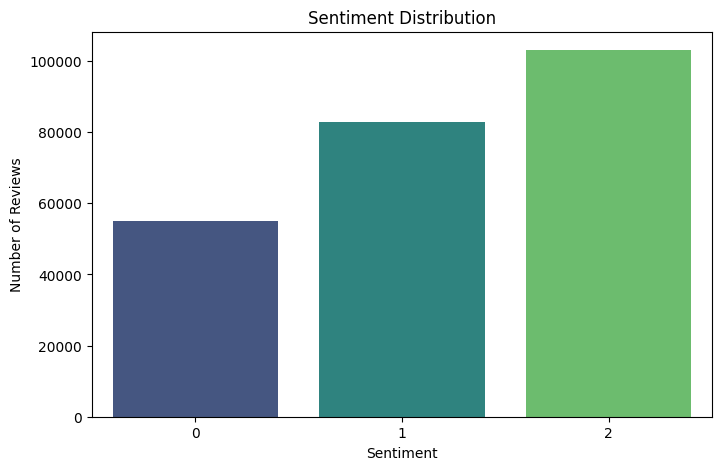

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df,
    palette='viridis'
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

## Sentiment Distribution

The sentiment distribution was visualized using a bar chart to understand the number of reviews in each sentiment category. This helps identify whether the dataset is balanced or imbalanced before training machine learning models. Balanced datasets generally help models learn more effectively across all classes.

The sentiment distribution shows that Class 2 contains the highest number of reviews, followed by Class 1 and Class 0. Although the dataset is not perfectly balanced, all three sentiment classes contain a sufficient number of samples for training machine learning models. A slight class imbalance exists, which should be considered while evaluating model performance.

In [15]:
# Display first 5 reviews
df['Comment'].head()


0    lets forget apple pay required brand new iphon...
1    nz retailers don’t even contactless credit car...
2    forever acknowledge channel help lessons ideas...
3    whenever go place doesn’t take apple pay doesn...
4    apple pay convenient secure easy use used kore...
Name: Comment, dtype: str

In [16]:
# Display one complete review
print(df['Comment'][0])

lets forget apple pay required brand new iphone order use significant portion apples user base wasnt able use even wanted successive iphone incorporated technology older iphones replaced number people could use technology increased


### Observation

A sample of the customer reviews was examined before applying any preprocessing techniques. It was observed that the text was already converted to lowercase and cleaned by the dataset creator. Most punctuation, URLs, numbers, and common stopwords had already been removed. Therefore, no additional preprocessing was required, and the dataset was ready for feature extraction using the TF-IDF Vectorizer.

In [17]:
#Tf-TDF Vector

# Separate features and target
X = df['Comment']
y = df['Sentiment']

# Create TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

# Convert text into numerical vectors
X_tfidf = tfidf.fit_transform(X)

# Display shape
print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (240928, 5000)


### Observation

The customer reviews were successfully transformed into numerical feature vectors using the TF-IDF Vectorizer. A maximum of 5000 important terms were selected from the dataset, creating a sparse numerical matrix that can now be used as input for machine learning algorithms such as Naive Bayes and Logistic Regression.

The customer reviews were successfully transformed into numerical feature vectors using the TF-IDF Vectorizer. The resulting matrix contains **240,928 reviews** represented by the **5000 most important textual features**. This numerical representation is now suitable for training machine learning classification models.

In [18]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (192742, 5000)
Testing Features Shape  : (48186, 5000)
Training Labels Shape   : (192742,)
Testing Labels Shape    : (48186,)


### Observation

The dataset was successfully split into training and testing sets using an 80:20 ratio. The training dataset contains **192,742 reviews**, while the testing dataset contains **48,186 reviews**. This ensures that the machine learning models are trained on one portion of the data and evaluated on previously unseen reviews, helping to measure their real-world performance.

In [20]:
# Import Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# Predict on test data
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


### Observation

The Multinomial Naive Bayes classifier was successfully trained using the TF-IDF feature vectors from the training dataset. The trained model generated sentiment predictions for the unseen testing dataset, which will be evaluated using multiple performance metrics in the next step.

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy_nb)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.6693230398871042

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.44      0.57     11023
           1       0.67      0.60      0.63     16631
           2       0.64      0.85      0.73     20532

    accuracy                           0.67     48186
   macro avg       0.70      0.63      0.64     48186
weighted avg       0.69      0.67      0.66     48186



In [22]:
#cofusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

print(cm_nb)

[[ 4892  2259  3872]
 [  666  9945  6020]
 [  576  2541 17415]]


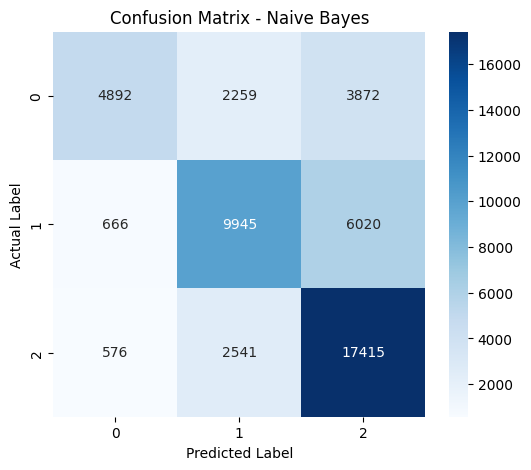

In [23]:
#plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [24]:
print("Accuracy:", accuracy_nb)

print(classification_report(y_test, y_pred_nb))

Accuracy: 0.6693230398871042
              precision    recall  f1-score   support

           0       0.80      0.44      0.57     11023
           1       0.67      0.60      0.63     16631
           2       0.64      0.85      0.73     20532

    accuracy                           0.67     48186
   macro avg       0.70      0.63      0.64     48186
weighted avg       0.69      0.67      0.66     48186



### Observation

The confusion matrix shows that the Naive Bayes model correctly classified a large number of reviews, especially for **Sentiment Class 2**. However, some reviews belonging to Classes 0 and 1 were incorrectly classified as Class 2. This indicates that while the model performs well overall, there is some confusion between sentiment classes due to similarities in the textual data and the slight class imbalance in the dataset.

The Multinomial Naive Bayes classifier achieved an **accuracy of 66.93%** on the testing dataset. The model performed best for **Sentiment Class 2**, achieving a recall of **85%** and an F1-score of **0.73**. However, the model struggled to correctly identify **Class 0**, resulting in a lower recall of **44%**. Overall, the classifier provides moderate performance and serves as a good baseline model for sentiment classification.

In [25]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Model 2: Logistic Regression

Logistic Regression is a supervised machine learning algorithm commonly used for text classification problems. It learns the relationship between TF-IDF features and sentiment labels to classify customer reviews into different sentiment categories.

In [26]:
#Accuracy Ans Classification repoert
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy_lr)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7889843523014983

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.66      0.72     11023
           1       0.75      0.83      0.79     16631
           2       0.83      0.83      0.83     20532

    accuracy                           0.79     48186
   macro avg       0.79      0.77      0.78     48186
weighted avg       0.79      0.79      0.79     48186



In [27]:
#confusion matrix value
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[ 7240  2113  1670]
 [  968 13823  1840]
 [ 1001  2576 16955]]


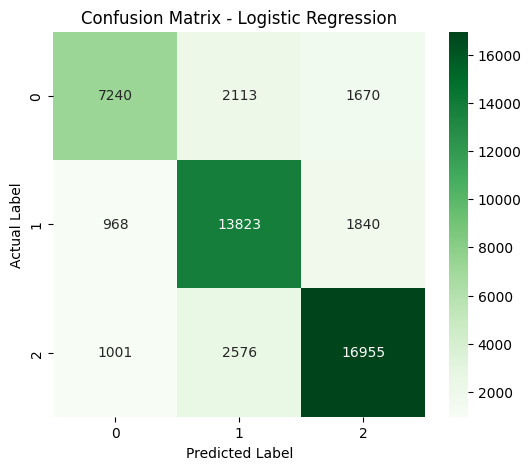

In [28]:
#comnfusion matrix heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Observation

The Logistic Regression model achieved an **accuracy of 78.90%**, outperforming the Naive Bayes classifier. The model demonstrated balanced performance across all three sentiment classes, achieving high Precision, Recall, and F1-scores. Compared to Naive Bayes, Logistic Regression produced fewer misclassifications and showed better generalization on unseen customer reviews.

## Model Comparison
| Metric | Naive Bayes | Logistic Regression |
|---------|-------------|--------------------|
| Accuracy | 66.93% | 78.90% |
| Precision | 0.69 | 0.79 |
| Recall | 0.67 | 0.79 |
| F1-Score | 0.66 | 0.79 |
| Best Model | ❌ | ✅ Logistic Regression |

## Conclusion

Two machine learning models were developed for sentiment classification: Multinomial Naive Bayes and Logistic Regression.

The Logistic Regression model achieved the highest accuracy (**78.90%**) and demonstrated superior Precision, Recall, and F1-score compared to Naive Bayes (**66.93%**).

Therefore, Logistic Regression was selected as the best-performing model for this sentiment analysis task. The trained model can effectively classify customer reviews into different sentiment categories and can assist businesses in understanding customer opinions at scale.

## Business Value

This sentiment analysis system enables organizations to automatically analyze large volumes of customer reviews and feedback.

The insights generated from sentiment classification can help businesses:

- Understand customer satisfaction levels.
- Detect negative feedback quickly.
- Improve products and services based on customer opinions.
- Support data-driven business decisions.
- Reduce manual effort required to analyze customer reviews.

In [29]:
#Error Analysis
# # Create a DataFrame for comparison

results = pd.DataFrame({
    'Review': X_test,
    'Actual Sentiment': y_test,
    'Predicted Sentiment': y_pred_lr
})

# Keep only misclassified reviews
misclassified = results[results['Actual Sentiment'] != results['Predicted Sentiment']]

# Display first 5 misclassified reviews
misclassified.head(5)

,Review,Actual Sentiment,Predicted Sentiment
168838,<Compressed Sparse Row sparse matrix of dtype ...,2,0
43329,<Compressed Sparse Row sparse matrix of dtype ...,1,0
123672,<Compressed Sparse Row sparse matrix of dtype ...,2,1
147339,<Compressed Sparse Row sparse matrix of dtype ...,0,1
3953,<Compressed Sparse Row sparse matrix of dtype ...,2,1


In [30]:
# Split original text also

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    df['Comment'],
    df['Sentiment'],
    test_size=0.20,
    random_state=42
)

In [31]:
#Erroe Analysis Table
error_df = pd.DataFrame({
    "Review": X_test_text.values,
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

# Misclassified reviews
misclassified = error_df[error_df["Actual"] != error_df["Predicted"]]

misclassified.head(5)

,Review,Actual,Predicted
11,answer jagans game plan cant retain state stop...,2,0
12,ha im ready cant believe balls call haha wtf,1,0
13,hope modi rallies,2,1
14,bitter truthalmost percent people constituency...,0,1
30,lets appreciate fact jperm almost remembered n...,2,1


### Observation

Five misclassified customer reviews were examined to understand the model's prediction errors. It was observed that most misclassifications occurred because the reviews contained ambiguous language, mixed sentiments, or lacked sufficient contextual information. Some reviews included both positive and negative expressions, making it difficult for the model to identify the correct sentiment. This highlights one of the common challenges in natural language processing, where understanding context is often more difficult than recognizing individual words.

In [33]:
from wordcloud import WordCloud
# Create separate datasets for each sentiment

negative_reviews = " ".join(df[df['Sentiment'] == 0]['Comment'])

neutral_reviews = " ".join(df[df['Sentiment'] == 1]['Comment'])

positive_reviews = " ".join(df[df['Sentiment'] == 2]['Comment'])

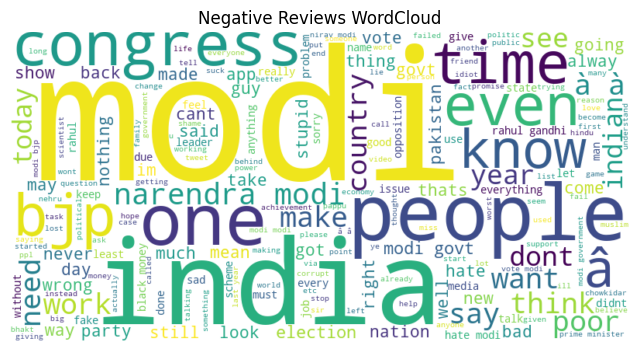

In [34]:
#negative reviews wordclud
plt.figure(figsize=(8,6))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

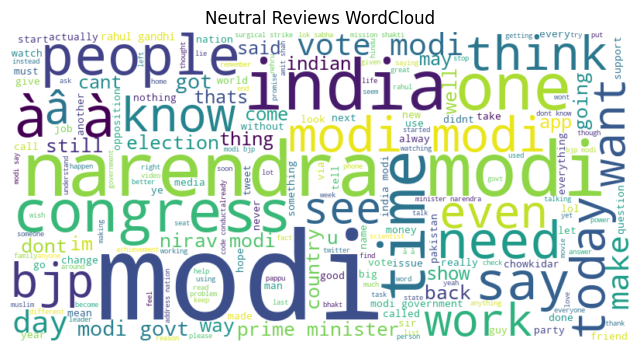

In [36]:
#Neutral 
plt.figure(figsize=(8,6))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(neutral_reviews)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Neutral Reviews WordCloud")
plt.show()

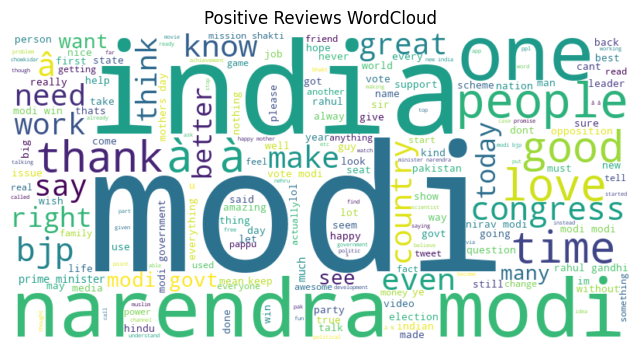

In [37]:
#positive
plt.figure(figsize=(8,6))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

### Observation

The WordCloud visualizations display the most frequently occurring words for each sentiment class.

- The **Negative WordCloud** is dominated by words such as *modi, congress, people, country,* and *vote*, indicating discussions related to politics and public opinion.
- The **Neutral WordCloud** contains commonly used words such as *people, modi, know, think,* and *government*, representing informative or descriptive discussions.
- The **Positive WordCloud** highlights frequently occurring positive discussion terms, showing the vocabulary commonly associated with favorable sentiments.

The WordClouds provide a quick visual understanding of the important words contributing to each sentiment category.

## Conclusion

Two machine learning models were developed for sentiment classification: Multinomial Naive Bayes and Logistic Regression.

The Logistic Regression model achieved the highest accuracy (**78.90%**) and demonstrated superior Precision, Recall, and F1-score compared to Naive Bayes (**66.93%**).

Therefore, Logistic Regression was selected as the best-performing model for this sentiment analysis task. The trained model can effectively classify customer reviews into different sentiment categories and can assist businesses in understanding customer opinions at scale.

## Business Value

This sentiment analysis system enables organizations to automatically analyze large volumes of customer reviews and feedback.

The insights generated from sentiment classification can help businesses:

- Understand customer satisfaction levels.
- Detect negative feedback quickly.
- Improve products and services based on customer opinions.
- Support data-driven business decisions.
- Reduce manual effort required to analyze customer reviews.

# Final Summary

This project successfully implemented a multi-class sentiment analysis system using Natural Language Processing (NLP) and Machine Learning techniques.

### Models Used
- Multinomial Naive Bayes
- Logistic Regression

### Best Performing Model
- Logistic Regression
- Accuracy: **78.90%**

### Key Techniques
- Data Cleaning
- TF-IDF Vectorization
- Train-Test Split
- Model Evaluation
- Confusion Matrix
- WordCloud Visualization
- Error Analysis

### Outcome
The Logistic Regression model achieved the highest accuracy and demonstrated balanced performance across all sentiment classes. This model can be used to automatically classify textual opinions and assist organizations in understanding public sentiment efficiently.